In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from sklearn.utils import class_weight
from torch.utils.data.sampler import WeightedRandomSampler

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
transform=transforms.Compose([
    transforms.Resize((128,128)),     #將圖片大小縮放至(128*128)
    transforms.ToTensor()
])

In [3]:
DATA_DIR = r'C:\Users\MJ\Desktop\seg'
model_algo="alexnet"


In [4]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,transform,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root, transform=transform)
        self.classes = self.images.class_to_idx.items()
        self.flag= [False] * len(self.images)
        self.decision_mode=decision_mode
        
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        
        if(self.decision_mode==False):
            image, label=self.images[idx]
            
            return image, label,idx
        else:
            image, _=self.images[idx]

            label=int(self.flag[idx])
            return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = True
    

In [5]:
#讀取資料且切分資料為train、valid、test

trainset=ImageDataset(DATA_DIR+"/seg_train",transform,decision_mode=False)
validset=ImageDataset(DATA_DIR+"/seg_test",transform,decision_mode=False)

train_size = len(trainset)
valid_size = len(validset)

# trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [6]:
# create data loaders
batch_size = 64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.classes}

In [7]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)
    if(data_name=='decision'):
        class_number=2
    else:
        class_number=len(trainset.classes)

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)
    
    return model

In [8]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [9]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [10]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        _, y_pred_tag = torch.max(out_growth, dim = 1)

                        out_predict= model(data)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
        
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                if(result==pred):
                                        correct+=1
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())

        decision_valid_accu=correct/valid_size

        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [11]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        overfitting = 0
        patience=3

        for epoch in range(epochs):
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out = model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                      
                        loss = criterion(out, target)
                        loss.backward()
                        optim.step()

                
                      
                train_loss,train_accu,_=evaluate_model(model,data_dl,len(data_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                elif(data_name=="decision"):
                        val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,valid_size)
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                elif (train_accu-best_val_accu>0.02):
                        overfitting += 1
                        
                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print("Early stopping!")
                        break
                elif overfitting >= patience:
                        print("Early stopping overfit!")
                        break

        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])


        plt.show()
        return model
                

In [12]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs):
    model=model_create(model_algo,data_name)

    criterion = nn.CrossEntropyLoss()

    optim = torch.optim.Adam(model.parameters(), lr=1e-4)
    if(data_name=="decision"):
        
        trainset.decision_mode=True
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
        trainset.decision_mode=False
    else:
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
    torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.24041851100179906,train_accu=0.9148496508479407
Epoch=0,valid_loss=0.31687778492768603,valid_accu=0.8913333333333333
Epoch=1,train_loss=0.20081815873818876,train_accu=0.9279606669516888
Epoch=1,valid_loss=0.34238186526298525,valid_accu=0.8816666666666667
Epoch=2,train_loss=0.09521852403951367,train_accu=0.9687900812312954
Epoch=2,valid_loss=0.2644788831075033,valid_accu=0.9076666666666666
Epoch=3,train_loss=0.06069962122369156,train_accu=0.9811172865897108
Epoch=3,valid_loss=0.26919637362162274,valid_accu=0.9076666666666666
Epoch=4,train_loss=0.04303607592236814,train_accu=0.9887416274761294
Epoch=4,valid_loss=0.29650889317194623,valid_accu=0.9073333333333333
Early stopping overfit!


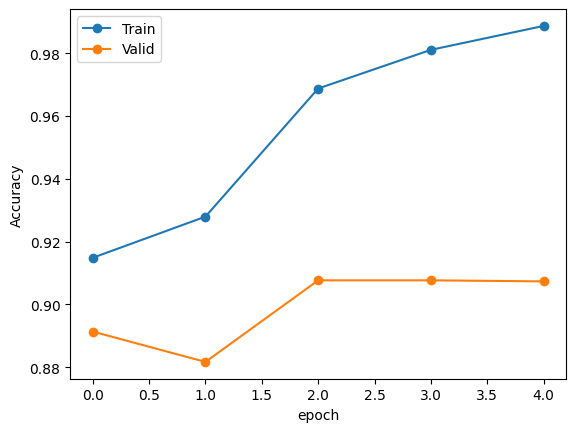

In [13]:
model_0=model_train(model_algo,train_dl,"0",20)
# model_0 = torch.load(f'model_{model_algo}_0.pth')

In [14]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.04303607742347378, 0.9887416274761294)

In [15]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.2965088915030162, 0.9073333333333333)

In [16]:
#將資料切分成true and false
def split_data(model_algo):
    model_0.eval()
  
    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in train_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for idx,result in zip(idx,torch.eq(target,y_pred_tag)):

                if(result.cpu().numpy()):
                    indexT.append(idx.cpu().numpy().item())
                    trainset.update_flag(idx)
                else:
                    indexF.append(idx.cpu().numpy().item())
            
        torch.cuda.empty_cache() 
    return indexF,indexT

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_algo)

Fdataset=Subset(trainset, indexF)
Tdataset=Subset(trainset, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
decision_dl = DataLoader(trainset, batch_size=batch_size)

In [18]:
# trainset.decision_mode=True
# labels = [label for _, label, _ in trainset]
# class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
# # Convert class weights to a dictionary format
# class_weights_dict = {idx: weight for idx, weight in enumerate(class_weights)}

# # Create a list of weights corresponding to each sample in the dataset
# weights = [class_weights_dict[label] for _, label, _ in trainset]

# # Create a sampler using WeightedRandomSampler
# sampler = WeightedRandomSampler(weights, len(weights))
# decision_dl = DataLoader(trainset, batch_size=batch_size, sampler=sampler)
# trainset.decision_mode=False

In [19]:
len(indexF),len(indexT)

(158, 13876)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.06896282719426708,train_accu=0.9887416274761294
decision_valid accu= 0.9073333333333333
Epoch=1,train_loss=0.07895832086926692,train_accu=0.9887416274761294
decision_valid accu= 0.9073333333333333
Epoch=2,train_loss=0.060990027390240995,train_accu=0.9887416274761294
decision_valid accu= 0.9073333333333333
Epoch=3,train_loss=0.057309076533085715,train_accu=0.9887416274761294
decision_valid accu= 0.9073333333333333
Early stopping overfit!


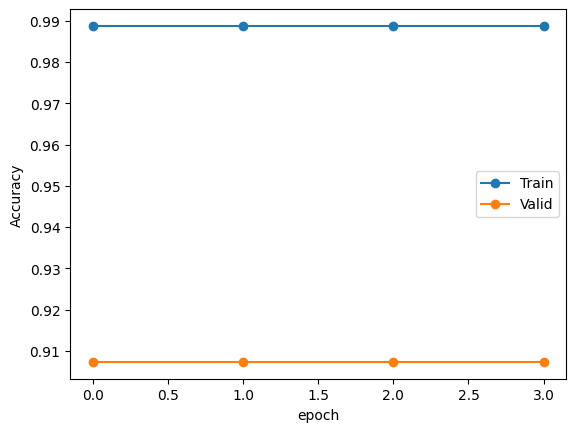

In [20]:
model_decision=model_train(model_algo,decision_dl,"decision",20)

# model_decision = torch.load(f'model_{model_algo}_decision.pth')

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.20054053711286365,train_accu=0.9380945517440185
Model_T valid loss=0.153107165030272, accu=0.9566495224099927,sample_number=2722
Epoch=1,train_loss=0.12301666847770858,train_accu=0.9597146151628712
Model_T valid loss=0.10074480568593132, accu=0.9698750918442322,sample_number=2722
Epoch=2,train_loss=0.0795282274989358,train_accu=0.9749207264341309
Model_T valid loss=0.08624658888076339, accu=0.973548861131521,sample_number=2722
Epoch=3,train_loss=0.05092840117468687,train_accu=0.9829201498991064
Model_T valid loss=0.09098453323765701, accu=0.9684055841293167,sample_number=2722
Epoch=4,train_loss=0.020367808088028797,train_accu=0.9961083885846065
Model_T valid loss=0.06799275088291092, accu=0.976120499632623,sample_number=2722
Epoch=5,train_loss=0.03978395402113619,train_accu=0.9860190256558086
Model_T valid loss=0.09729465151792648, accu=0.964731814842028,sample_number=2722
Epoch=6,train_loss=0.02196839013915218,train_accu=0.9929374459498415
Model_T valid loss=0.094

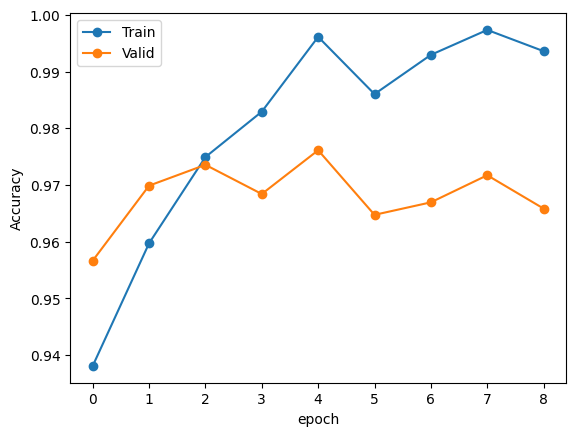

In [21]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,"T",20)
# model_T=torch.load(f'model_{model_algo}_T.pth')

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.9373099743565426,train_accu=0.6455696202531646
Model_F valid loss=1.4689206725937858, accu=0.4172661870503597,sample_number=278
Epoch=1,train_loss=0.6825789711143397,train_accu=0.7468354430379747
Model_F valid loss=1.412283579302992, accu=0.45323741007194246,sample_number=278
Epoch=2,train_loss=0.5147845752631561,train_accu=0.8227848101265823
Model_F valid loss=1.3661352339595985, accu=0.4676258992805755,sample_number=278
Epoch=3,train_loss=0.38724025216283675,train_accu=0.8987341772151899
Model_F valid loss=1.3703867935327638, accu=0.49280575539568344,sample_number=278
Epoch=4,train_loss=0.26130417064775396,train_accu=0.930379746835443
Model_F valid loss=1.3808705318055832, accu=0.5,sample_number=278
Epoch=5,train_loss=0.18303620871863788,train_accu=0.9367088607594937
Model_F valid loss=1.5769403078995323, accu=0.49280575539568344,sample_number=278
Epoch=6,train_loss=0.10214164853096008,train_accu=0.9810126582278481
Model_F valid loss=1.6121989230653808, accu=0.50

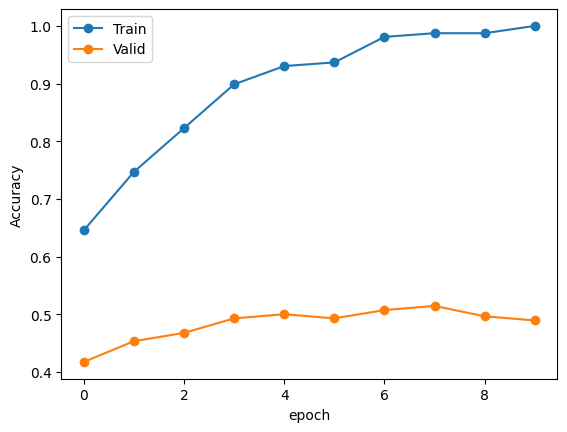

In [22]:
model_F=model_train(model_algo,Fdl,"F",30)
# model_F=torch.load(f'model_{model_algo}_F.pth')

In [23]:
torch.cuda.empty_cache()

In [24]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.01904835085268837, 0.993586047852407)

In [25]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.022344543398181094, 1.0)

In [26]:
trainset.decision_mode=True
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,train_size)
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
trainset.decision_mode=False
decision_loss,decision_accu

(0.057309076533085715, 0.9887416274761294)

In [27]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")
decision_valid_accu,confusion_matrix_decision_valid=evaluate_model_decision(model_decision )
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})

Model_T valid loss=0.1075411986752478, accu=0.9658339456282146,sample_number=2722
Model_F valid loss=2.177184388596746, accu=0.4892086330935252,sample_number=278
decision_valid accu= 0.9073333333333333


In [28]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total
        

In [29]:
total_train_loss,total_train_accu,confusion_matrix_total_train=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu

(0.09313411577006458, 0.9841100185264358)

In [30]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu

(0.44904161055882774, 0.9073333333333333)

In [31]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))

    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [32]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,"NA",T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [33]:
model_algos=['Model_0',"Model_decision","Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.043036,0.988742,0.296509,0.907333
1,Model_decision,0.057309,0.988742,NA,0.907333
2,Model_T,0.019048,0.993586,0.107541,0.965834
3,Model_F,0.022345,1.000000,2.177184,0.489209
4,Total_Model,0.093134,0.984110,0.449042,0.907333


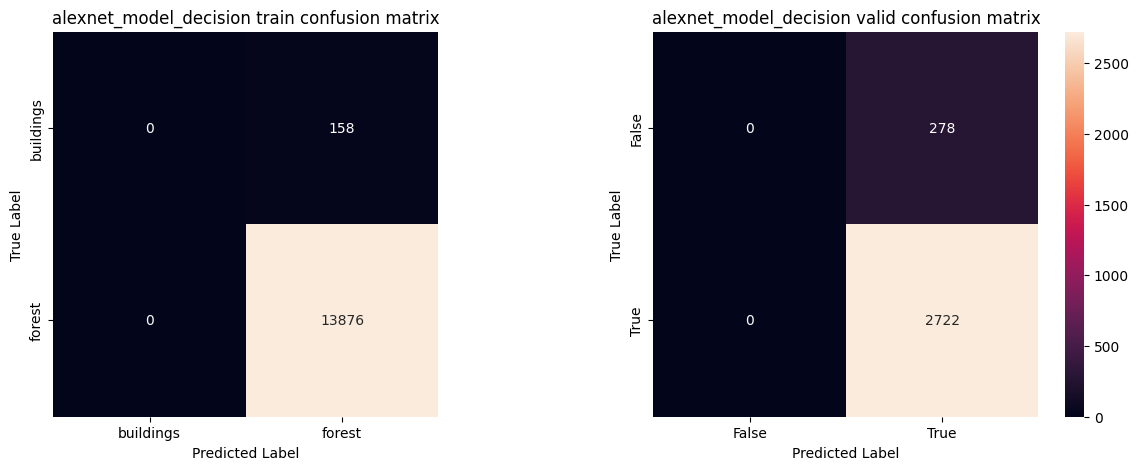

In [34]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

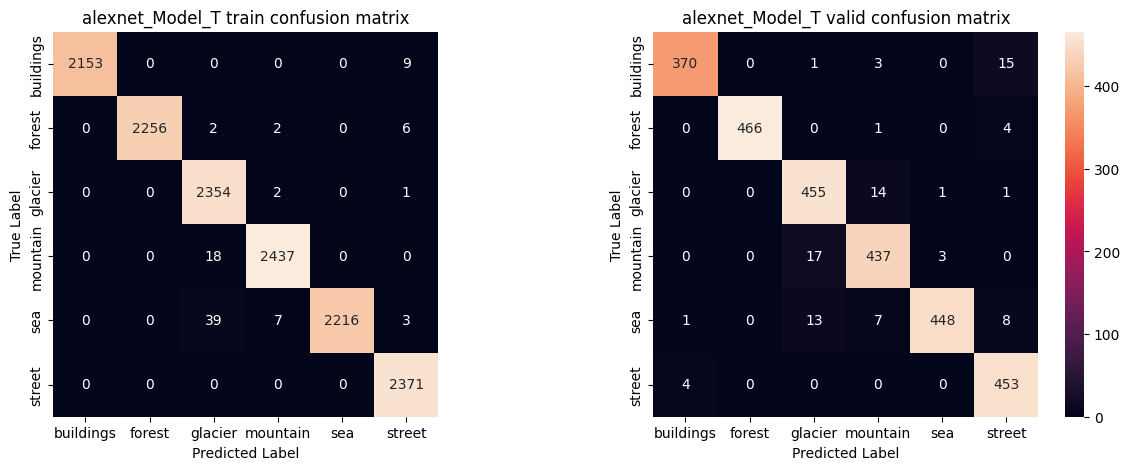

In [35]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

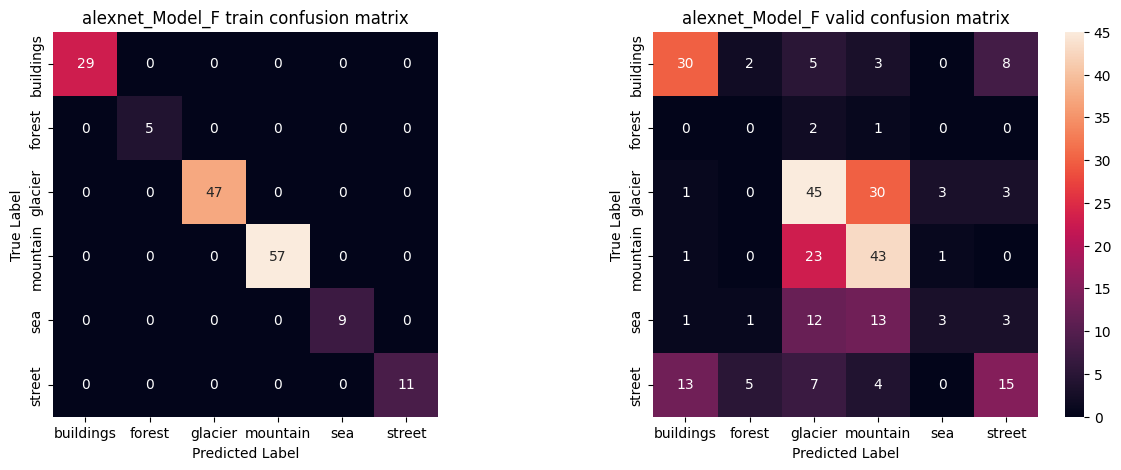

In [36]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

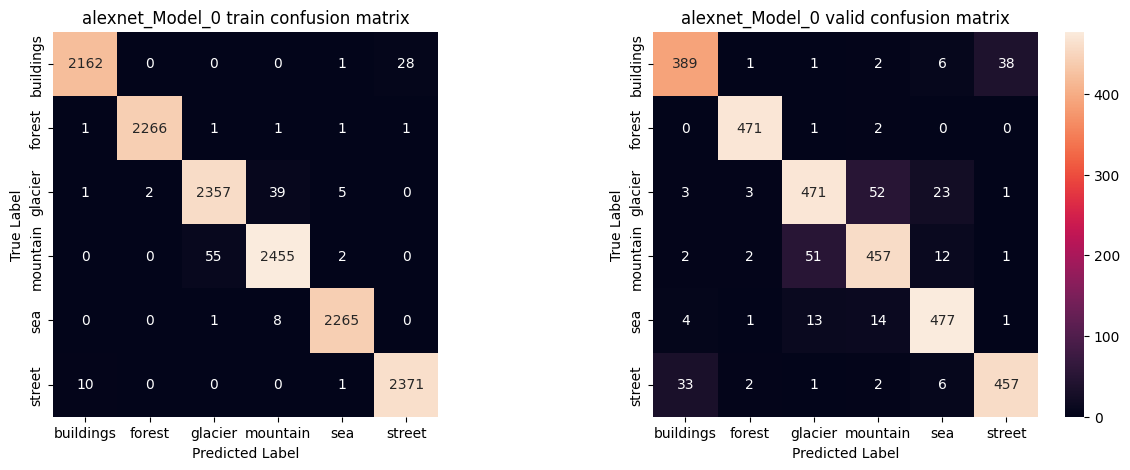

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

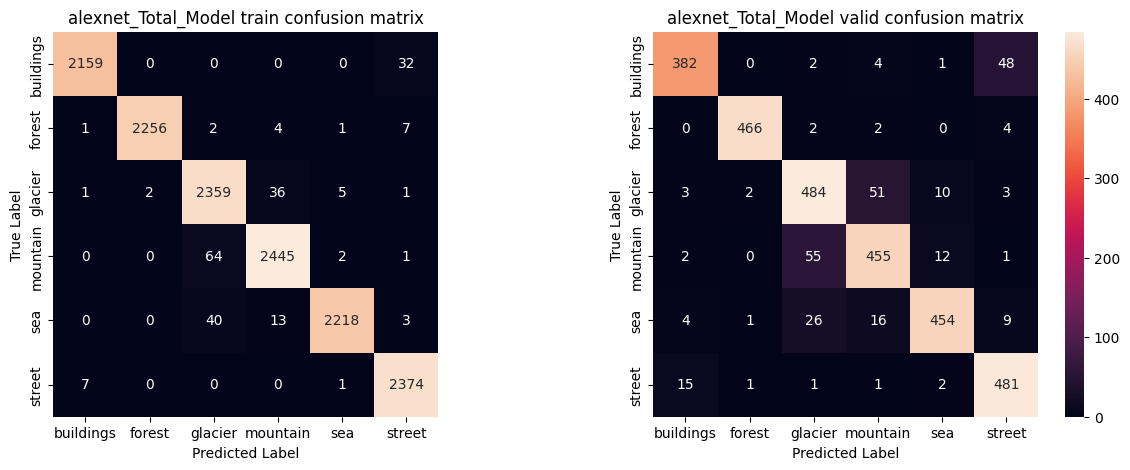

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")